<a href="https://colab.research.google.com/github/taanish241013006048/AI-ML-LAB/blob/main/prob_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install networkx matplotlib

BFS Traversal: A -> B -> C -> D -> E -> F
DFS Traversal: A -> B -> D -> E -> C -> F


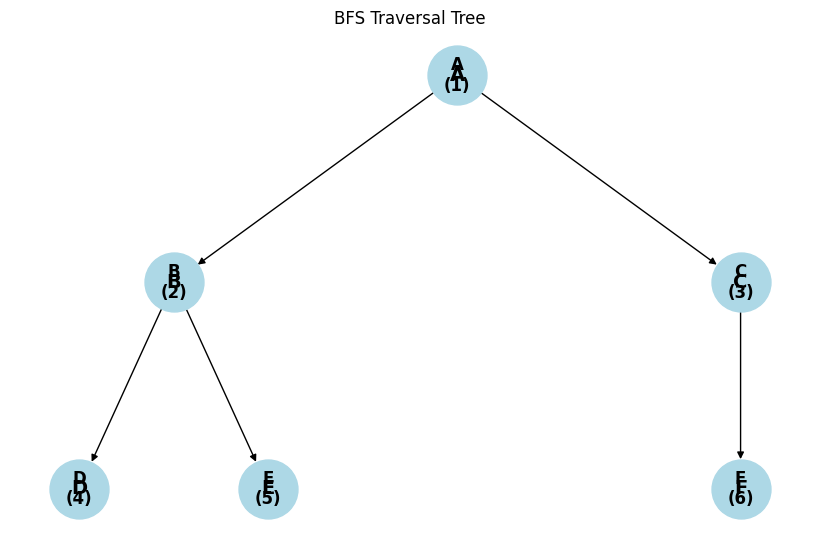

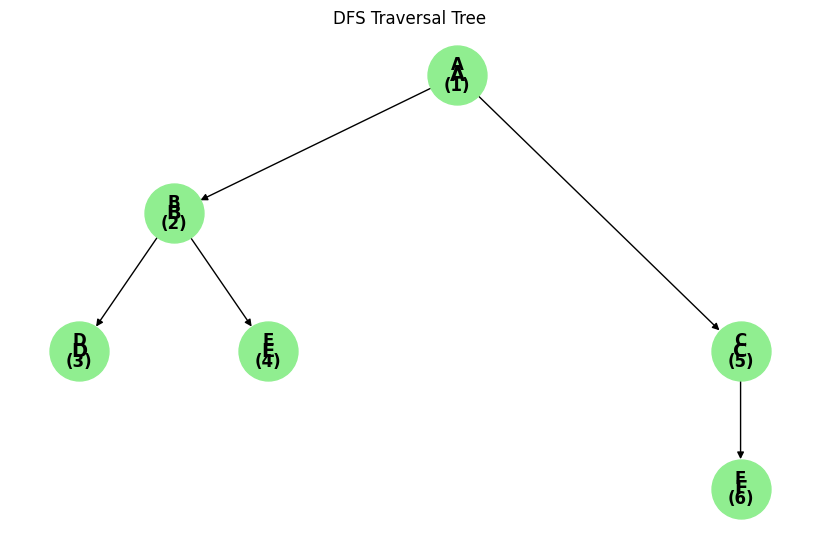

In [ ]:

import networkx as nx
import matplotlib.pyplot as plt
from collections import deque


graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': [],
    'F': []
}


def bfs(graph, start):
    visited = set()
    queue = deque([start])
    traversal = []

    visited.add(start)

    while queue:
        node = queue.popleft()
        traversal.append(node)

        for neighbour in graph[node]:
            if neighbour not in visited:
                visited.add(neighbour)
                queue.append(neighbour)

    return traversal



def dfs(graph, start):
    visited = set()
    traversal = []

    def dfs_recursive(node):
        visited.add(node)
        traversal.append(node)

        for neighbour in graph[node]:
            if neighbour not in visited:
                dfs_recursive(neighbour)

    dfs_recursive(start)

    return traversal


bfs_order = bfs(graph, 'A')
dfs_order = dfs(graph, 'A')


print("BFS Traversal:", " -> ".join(bfs_order))
print("DFS Traversal:", " -> ".join(dfs_order))



def draw_bfs_tree(graph, traversal):
    G = nx.DiGraph()


    visited = set()
    queue = deque(['A'])
    visited.add('A')

    while queue:
        node = queue.popleft()

        for neighbour in graph[node]:
            if neighbour not in visited:
                visited.add(neighbour)
                queue.append(neighbour)
                G.add_edge(node, neighbour)


    pos = {
        'A': (0, 2),
        'B': (-1.5, 1),
        'C': (1.5, 1),
        'D': (-2, 0),
        'E': (-1, 0),
        'F': (1.5, 0)
    }

    plt.figure(figsize=(8, 5))

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_size=1800,
        node_color='lightblue',
        font_size=14,
        font_weight='bold',
        arrows=True
    )


    labels = {
        node: f"{node}\n({traversal.index(node) + 1})"
        for node in G.nodes()
    }

    nx.draw_networkx_labels(
        G,
        pos,
        labels=labels,
        font_size=12,
        font_weight='bold'
    )

    plt.title("BFS Traversal Tree")
    plt.axis("off")
    plt.show()



def draw_dfs_tree(graph, traversal):
    G = nx.DiGraph()


    visited = set()

    def dfs_tree(node):
        visited.add(node)

        for neighbour in graph[node]:
            if neighbour not in visited:
                G.add_edge(node, neighbour)
                dfs_tree(neighbour)

    dfs_tree('A')


    pos = {
        'A': (0, 2),
        'B': (-1.5, 1),
        'C': (1.5, 0),
        'D': (-2, 0),
        'E': (-1, 0),
        'F': (1.5, -1)
    }

    plt.figure(figsize=(8, 5))

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_size=1800,
        node_color='lightgreen',
        font_size=14,
        font_weight='bold',
        arrows=True
    )


    labels = {
        node: f"{node}\n({traversal.index(node) + 1})"
        for node in G.nodes()
    }

    nx.draw_networkx_labels(
        G,
        pos,
        labels=labels,
        font_size=12,
        font_weight='bold'
    )

    plt.title("DFS Traversal Tree")
    plt.axis("off")
    plt.show()



draw_bfs_tree(graph, bfs_order)
draw_dfs_tree(graph, dfs_order)